Top 3 Matching Images:


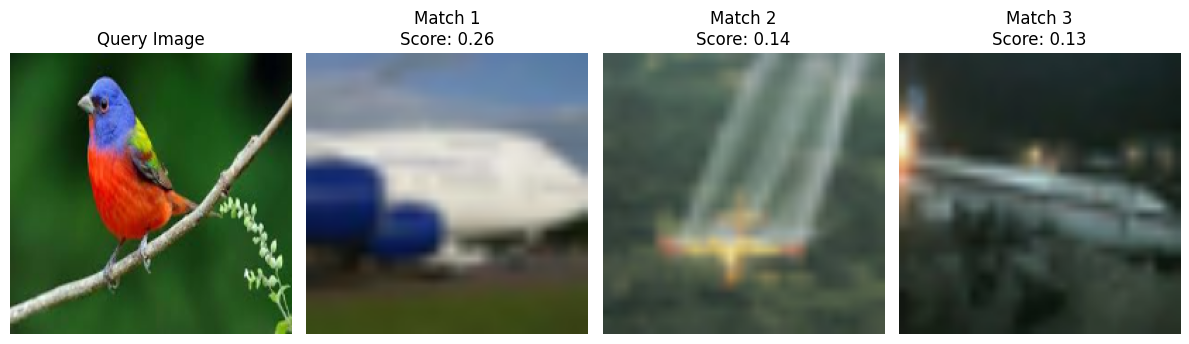

In [1]:
# Code Example 1: Extract and Compare Color Histograms
import cv2 
import numpy as np 
import matplotlib.pyplot as plt
import os
dataset_path = "D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/CIFAR-10/cifar10/test"
query_path = "D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/M32.jpg"
def get_histogram(img): 
    hist = cv2.calcHist([img], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256]) 
    cv2.normalize(hist, hist) 
    return hist.flatten()
query = cv2.imread(query_path) 
if query is None:
    print("Error: Query image not found!")
query = cv2.resize(query, (200, 200)) 
query_hist = get_histogram(query)
scores = [] 
max_images = 150  
count = 0
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')): 
            image_path = os.path.join(root, file) 
            image = cv2.imread(image_path) 
            if image is None:
                continue
            image = cv2.resize(image, (200, 200)) 
            hist = get_histogram(image) 
            score = cv2.compareHist(query_hist, hist, cv2.HISTCMP_CORREL) 
            scores.append((score, file, image))
            count += 1
            if count >= max_images:
                break
    if count >= max_images:
        break
scores.sort(reverse=True) 
top_matches = scores[:3] 
print("Top 3 Matching Images:") 
plt.figure(figsize=(12, 6))
plt.subplot(1, 4, 1) 
plt.imshow(cv2.cvtColor(query, cv2.COLOR_BGR2RGB)) 
plt.title("Query Image") 
plt.axis('off')
for i, (score, fname, img) in enumerate(top_matches): 
    plt.subplot(1, 4, i + 2) 
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) 
    plt.title(f"Match {i+1}\nScore: {score:.2f}") 
    plt.axis('off') 
plt.tight_layout() 
plt.show()

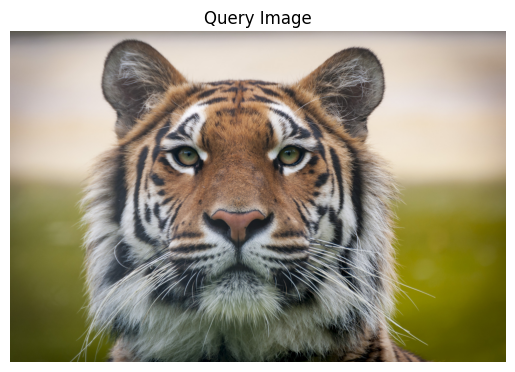

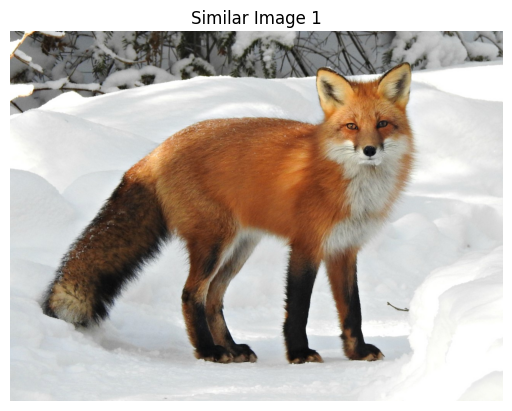

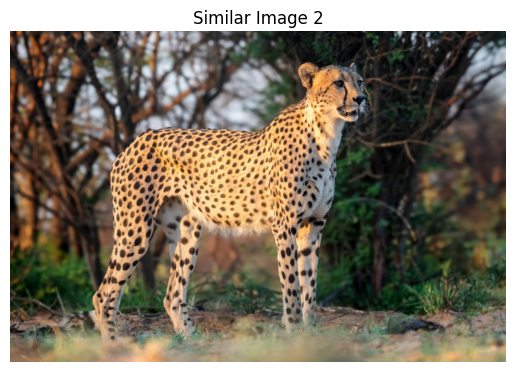

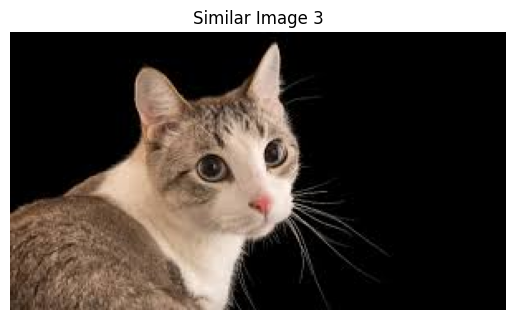

In [2]:
# Code Example 2: Wildlife Image Retrieval using Color-Based Content Analysis
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.metrics.pairwise import cosine_similarity
def extract_color_histogram(image, bins=(8, 8, 8)): 
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV) 
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0,180, 0,256, 0,256]) 
    return hist.flatten()
img = cv2.imread("D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/M28.jpg") 
query_features = extract_color_histogram(img)
dataset = [] 
dataset.append(cv2.imread("D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/M29.jpg")) 
dataset.append(cv2.imread("D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/M30.jpg")) 
dataset.append(cv2.imread("D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/M31.jpg"))
dataset_features = [extract_color_histogram(image) for image in dataset]
similarities = [cosine_similarity([query_features], [features])[0][0] for features in dataset_features]
ranked_indices = sorted(range(len(similarities)), key=lambda i: similarities[i], reverse=True) 
plt.figure() 
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) 
plt.title('Query Image') 
plt.axis('off') 
plt.show() 
top_k = 3 
for i in range(top_k): 
    similar_img = dataset[ranked_indices[i]] 
    plt.figure() 
    plt.imshow(cv2.cvtColor(similar_img, cv2.COLOR_BGR2RGB)) 
    plt.title(f"Similar Image {i+1}") 
    plt.axis('off') 
    plt.show()

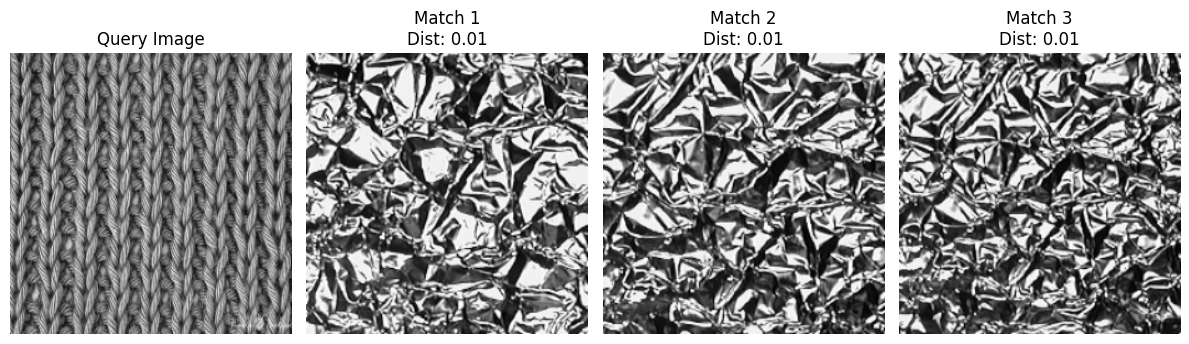

In [3]:
# Code Example 3: Texture-Based Defect Detection in Fabric Inspection
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 
from skimage.feature import local_binary_pattern
import os
dataset_path = "D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/KTH TIPS-2/KTH_TIPS"
query_img_path = "D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/M24.jpg"
def extract_lbp_features(gray_img): 
    lbp = local_binary_pattern(gray_img, P=24, R=3, method="uniform") 
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 27), range=(0, 26)) 
    hist = hist.astype("float") 
    hist /= (hist.sum() + 1e-6) 
    return hist
query_img = cv2.imread(query_img_path, cv2.IMREAD_GRAYSCALE) 
query_img = cv2.resize(query_img, (256, 256))
query_hist = extract_lbp_features(query_img)
def chi2_distance(histA, histB, eps=1e-6): 
    return 0.5 * np.sum(((histA - histB) ** 2) / (histA + histB + eps))
scores = [] 
for root, dirs, files in os.walk(dataset_path): 
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')): 
            img_path = os.path.join(root, file) 
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) 
            if img is None:
                continue
            img = cv2.resize(img, (256, 256)) 
            hist = extract_lbp_features(img) 
            dist = chi2_distance(query_hist, hist)
            scores.append((dist, file, img))
scores.sort(key=lambda x: x[0]) 
top_matches = scores[:3] 
plt.figure(figsize=(12, 6)) 
plt.subplot(1, 4, 1) 
plt.imshow(query_img, cmap='gray') 
plt.title("Query Image") 
plt.axis('off') 
for i, (dist, fname, img) in enumerate(top_matches): 
    plt.subplot(1, 4, i + 2) 
    plt.imshow(img, cmap='gray') 
    plt.title(f"Match {i+1}\nDist: {dist:.2f}") 
    plt.axis('off') 
plt.tight_layout() 
plt.show()

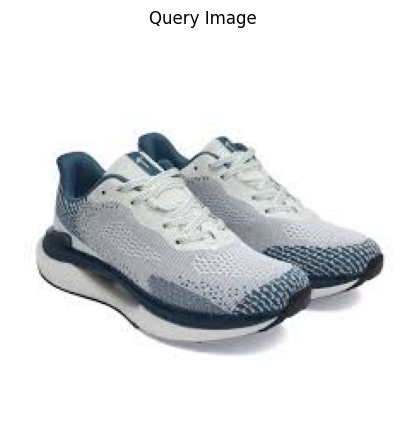

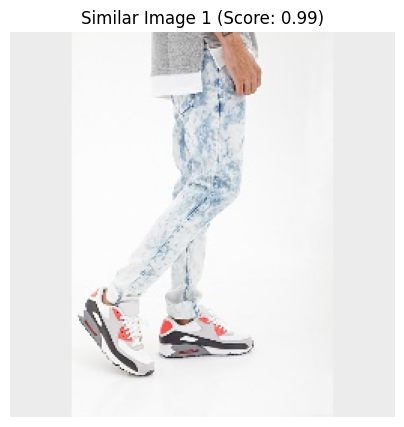

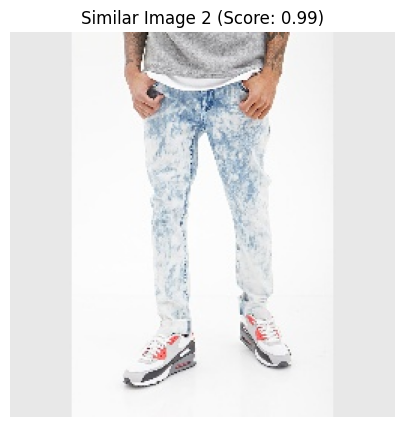

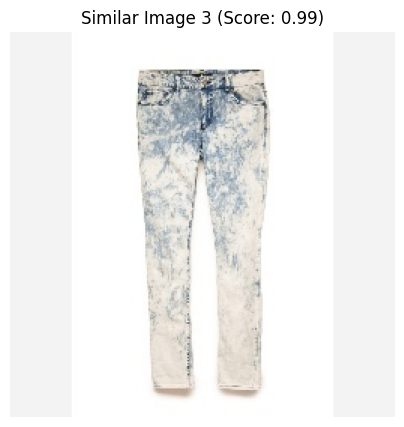

In [4]:
# Case Study 1: Fashion E-Commerce Image Search
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.metrics.pairwise import cosine_similarity 
import os 
dataset_path = "D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/DEEPFASHION/img/img"
query_path = "D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/M33.jpg"
def extract_color_histogram(image, bins=(8, 8, 8)): 
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV) 
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0,180, 0,256, 0,256]) 
    cv2.normalize(hist, hist) 
    return hist.flatten() 
def extract_gray_histogram(image, bins=256): 
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 
    hist = cv2.calcHist([gray], [0], None, [bins], [0, 256]) 
    cv2.normalize(hist, hist) 
    return hist.flatten() 
query_img = cv2.imread(query_path)
if query_img is None:
    raise ValueError("Query image not found!")
query_features_fashion = extract_color_histogram(query_img) 
query_features_medical = extract_gray_histogram(query_img) 
dataset_imgs = [] 
dataset_fashion_features = [] 
dataset_medical_features = [] 
max_images = 150
count = 0
for root, dirs, files in os.walk(dataset_path): 
    for filename in files:
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(root, filename)
            img = cv2.imread(img_path)    
            if img is None:
                continue   
            dataset_imgs.append(img) 
            dataset_fashion_features.append(extract_color_histogram(img)) 
            dataset_medical_features.append(extract_gray_histogram(img)) 
            count += 1
            if count >= max_images:
                break
    if count >= max_images:
        break
mode = 'fashion' 
if mode == 'fashion': 
    query_features = query_features_fashion 
    dataset_features = dataset_fashion_features 
elif mode == 'medical': 
    query_features = query_features_medical 
    dataset_features = dataset_medical_features 
similarities = [cosine_similarity([query_features], [feat])[0][0] for feat in dataset_features] 
ranked_indices = sorted(range(len(similarities)), key=lambda i: similarities[i], reverse=True) 

plt.figure(figsize=(5,5)) 
plt.imshow(cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB)) 
plt.title('Query Image') 
plt.axis('off') 
plt.show() 
top_k = 3 
for i in range(min(top_k, len(dataset_imgs))): 
    idx = ranked_indices[i] 
    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(dataset_imgs[idx], cv2.COLOR_BGR2RGB)) 
    plt.title(f"Similar Image {i+1} (Score: {similarities[idx]:.2f})") 
    plt.axis('off') 
    plt.show()

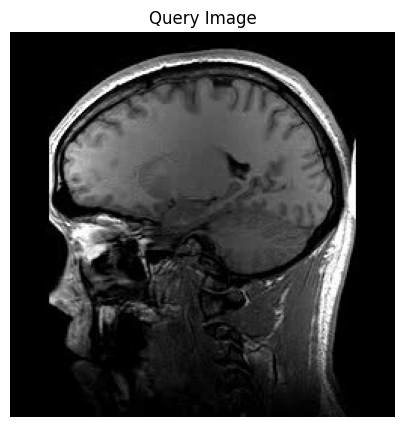

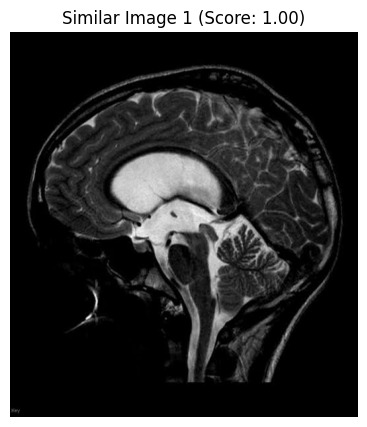

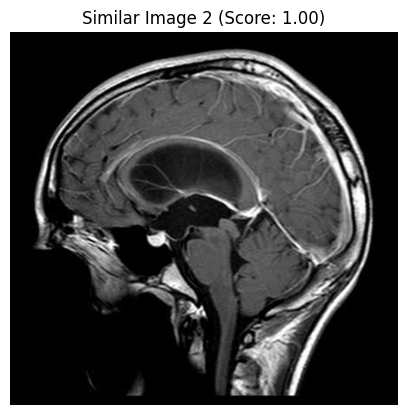

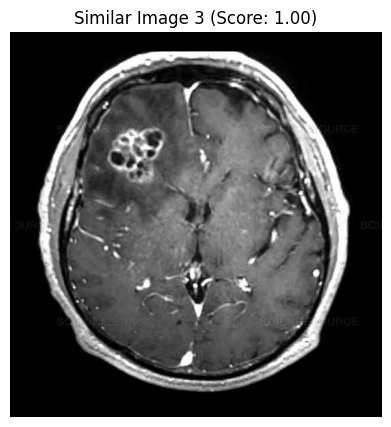

In [5]:
# Case Study 2: Medical Imaging Systems
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.metrics.pairwise import cosine_similarity 
import os 
dataset_path = "D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/BRAIN TUMOR MRI"
query_path = "D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/M20.jpg" 
def extract_color_histogram(image, bins=(8, 8, 8)): 
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV) 
    hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0,180, 0,256, 0,256]) 
    cv2.normalize(hist, hist) 
    return hist.flatten()  
def extract_gray_histogram(image, bins=256): 
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 
    hist = cv2.calcHist([gray], [0], None, [bins], [0, 256]) 
    cv2.normalize(hist, hist) 
    return hist.flatten() 
query_img = cv2.imread(query_path) 
if query_img is None:
    raise ValueError("Query image not found!") 
query_features_fashion = extract_color_histogram(query_img) 
query_features_medical = extract_gray_histogram(query_img) 
dataset_imgs = [] 
dataset_fashion_features = [] 
dataset_medical_features = [] 
max_images = 150
count = 0
for root, dirs, files in os.walk(dataset_path): 
    for filename in files:
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(root, filename)
            img = cv2.imread(img_path) 
            if img is None:
                continue
            dataset_imgs.append(img) 
            dataset_fashion_features.append(extract_color_histogram(img)) 
            dataset_medical_features.append(extract_gray_histogram(img))  
            count += 1
            if count >= max_images:
                break
    if count >= max_images:
        break
mode = 'medical'
if mode == 'fashion': 
    query_features = query_features_fashion 
    dataset_features = dataset_fashion_features 
elif mode == 'medical': 
    query_features = query_features_medical 
    dataset_features = dataset_medical_features 
similarities = [cosine_similarity([query_features], [feat])[0][0] for feat in dataset_features] 
ranked_indices = sorted(range(len(similarities)), key=lambda i: similarities[i], reverse=True) 
plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB)) 
plt.title('Query Image') 
plt.axis('off') 
plt.show() 
top_k = 3 
for i in range(min(top_k, len(dataset_imgs))): 
    idx = ranked_indices[i] 
    plt.figure(figsize=(5,5)) 
    plt.imshow(cv2.cvtColor(dataset_imgs[idx], cv2.COLOR_BGR2RGB)) 
    plt.title(f"Similar Image {i+1} (Score: {similarities[idx]:.2f})") 
    plt.axis('off') 
    plt.show()

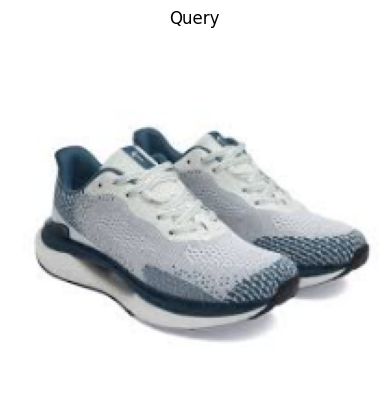

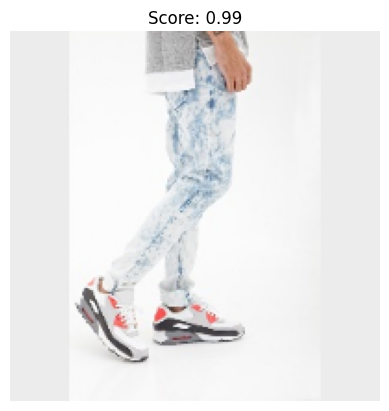

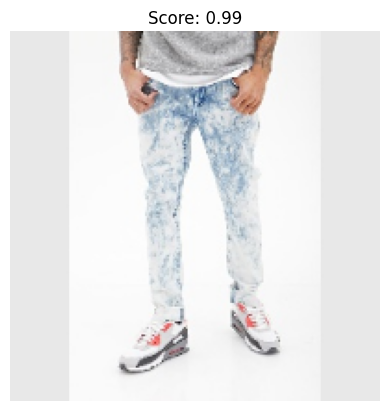

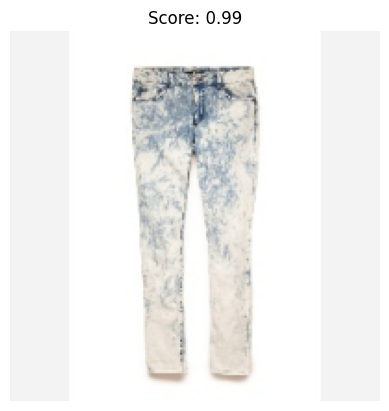

In [6]:
# Case Study 1: Fashion Retail – Visual Product Search
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics.pairwise import cosine_similarity
dataset_path = "D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/DEEPFASHION/img/img"
query_path = "D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/M33.jpg"
def feature(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv],[0,1,2],None,[8,8,8],[0,180,0,256,0,256])
    cv2.normalize(hist,hist)
    return hist.flatten()
query = cv2.imread(query_path)
if query is None:
    raise ValueError("Query image not found!")
query = cv2.resize(query,(200,200))
query_feat = feature(query)
images, features = [], []
max_images = 150
count = 0
for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img = cv2.imread(os.path.join(root,file))
            if img is None: 
                continue
            img = cv2.resize(img,(200,200))
            images.append(img)
            features.append(feature(img))
            count += 1
            if count >= max_images:
                break
    if count >= max_images:
        break
scores = [cosine_similarity([query_feat],[f])[0][0] for f in features]
idx = np.argsort(scores)[::-1][:3]
plt.imshow(cv2.cvtColor(query,cv2.COLOR_BGR2RGB))
plt.title("Query")
plt.axis("off")
plt.show()
for i in idx:
    plt.imshow(cv2.cvtColor(images[i],cv2.COLOR_BGR2RGB))
    plt.title(f"Score: {scores[i]:.2f}")
    plt.axis("off")
    plt.show()

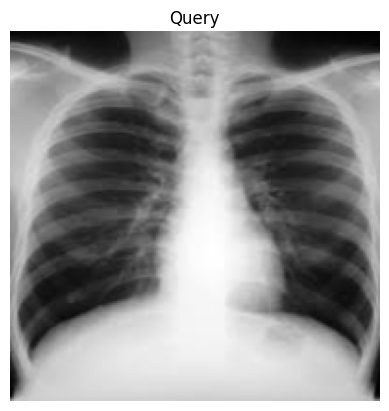

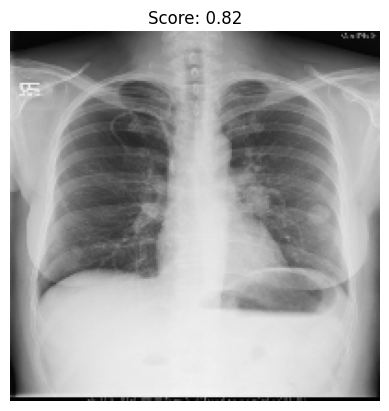

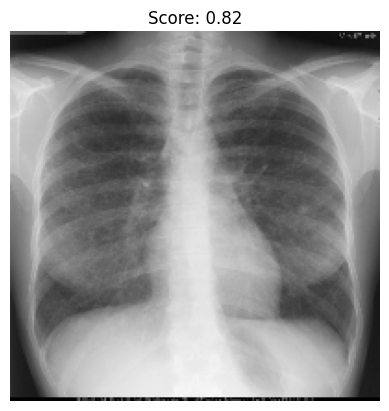

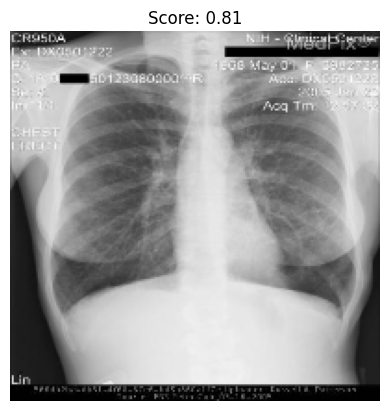

In [7]:
# Case Study 2: Medical Imaging – Case Matching for Diagnosis Support
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics.pairwise import cosine_similarity
dataset_path = dataset_path = "D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/MEDPIX/images/images"
query_path = "D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/M8.jpg"
def feature(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hist = cv2.calcHist([gray],[0],None,[256],[0,256])
    cv2.normalize(hist,hist)
    return hist.flatten()
query = cv2.imread(query_path)
if query is None:
    raise ValueError("Query image not found!")
query = cv2.resize(query,(200,200))
query_feat = feature(query)
images, features = [], []
max_images = 150
count = 0
for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img = cv2.imread(os.path.join(root,file))
            if img is None: 
                continue
            img = cv2.resize(img,(200,200))
            images.append(img)
            features.append(feature(img))
            count += 1
            if count >= max_images:
                break
    if count >= max_images:
        break
scores = [cosine_similarity([query_feat],[f])[0][0] for f in features]
idx = np.argsort(scores)[::-1][:3]
plt.imshow(cv2.cvtColor(query,cv2.COLOR_BGR2RGB))
plt.title("Query")
plt.axis("off")
plt.show()
for i in idx:
    plt.imshow(cv2.cvtColor(images[i],cv2.COLOR_BGR2RGB))
    plt.title(f"Score: {scores[i]:.2f}")
    plt.axis("off")
    plt.show()

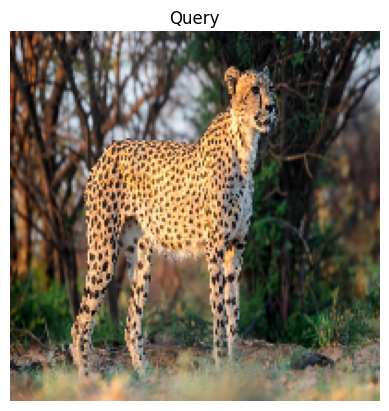

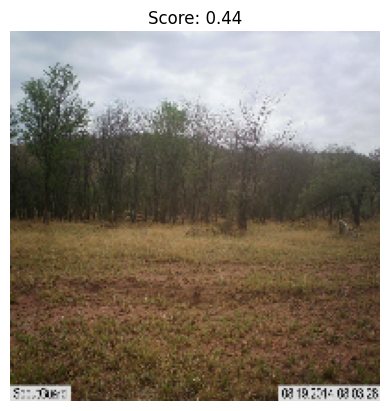

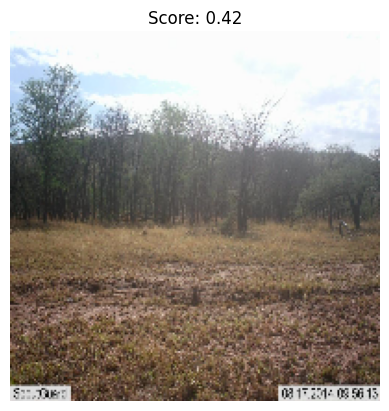

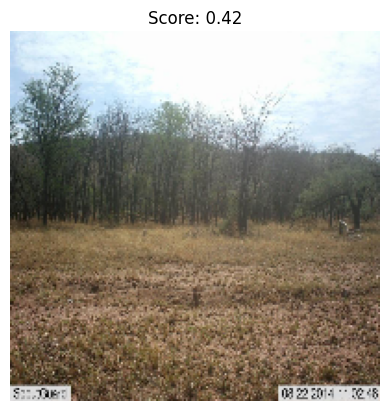

In [9]:
# Case Study 3: Wildlife Monitoring – Animal Identification from Camera Traps
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics.pairwise import cosine_similarity
dataset_path = "D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/SERENGETI/test"
query_path = "D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/M31.jpg"
def feature(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv],[0,1,2],None,[8,8,8],[0,180,0,256,0,256])
    cv2.normalize(hist,hist)
    return hist.flatten()
query = cv2.imread(query_path)
if query is None:
    raise ValueError("Query image not found!")
query = cv2.resize(query,(200,200))
query_feat = feature(query)
images, features = [], []
max_images = 150
count = 0
for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img = cv2.imread(os.path.join(root,file))
            if img is None:
                continue
            img = cv2.resize(img,(200,200))
            images.append(img)
            features.append(feature(img))
            count += 1
            if count >= max_images:
                break
    if count >= max_images:
        break
scores = [cosine_similarity([query_feat],[f])[0][0] for f in features]
idx = np.argsort(scores)[::-1][:3]
plt.imshow(cv2.cvtColor(query,cv2.COLOR_BGR2RGB))
plt.title("Query")
plt.axis("off")
plt.show()
for i in idx:
    plt.imshow(cv2.cvtColor(images[i],cv2.COLOR_BGR2RGB))
    plt.title(f"Score: {scores[i]:.2f}")
    plt.axis("off")
    plt.show()

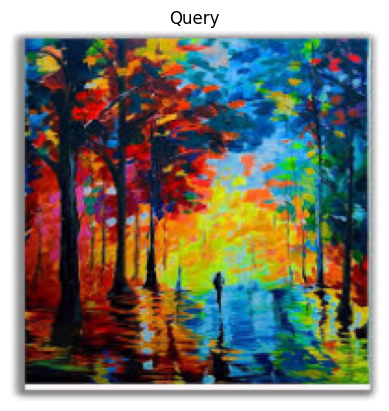

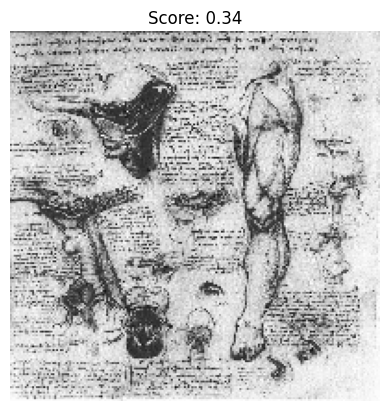

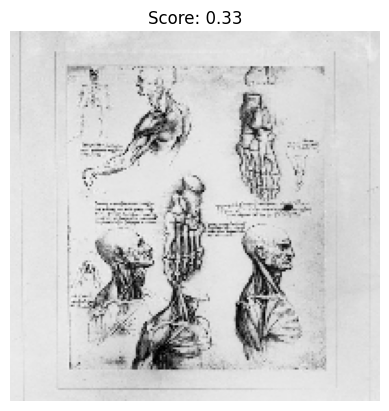

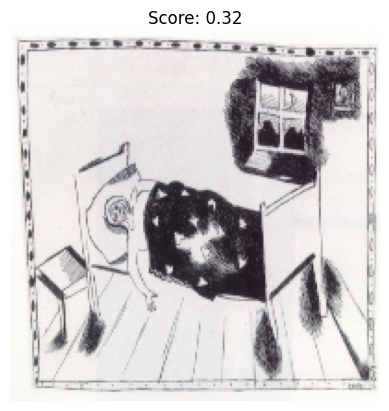

In [10]:
# Case Study 4: Art Museum – Artwork Recommendation System
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics.pairwise import cosine_similarity
dataset_path = "D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/PAINTER BY NUMBERS"
query_path = "D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/M34.jpg"
def feature(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv],[0,1,2],None,[8,8,8],[0,180,0,256,0,256])
    cv2.normalize(hist,hist)
    return hist.flatten()
query = cv2.imread(query_path)
if query is None:
    raise ValueError("Query image not found!")
query = cv2.resize(query,(200,200))
query_feat = feature(query)
images, features = [], []
max_images = 150
count = 0
for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(root,file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img,(200,200))
            images.append(img)
            features.append(feature(img))
            count += 1
            if count >= max_images:
                break
    if count >= max_images:
        break
scores = [cosine_similarity([query_feat],[f])[0][0] for f in features]
idx = np.argsort(scores)[::-1][:3]
plt.imshow(cv2.cvtColor(query,cv2.COLOR_BGR2RGB))
plt.title("Query")
plt.axis("off")
plt.show()
for i in idx:
    plt.imshow(cv2.cvtColor(images[i],cv2.COLOR_BGR2RGB))
    plt.title(f"Score: {scores[i]:.2f}")
    plt.axis("off")
    plt.show()

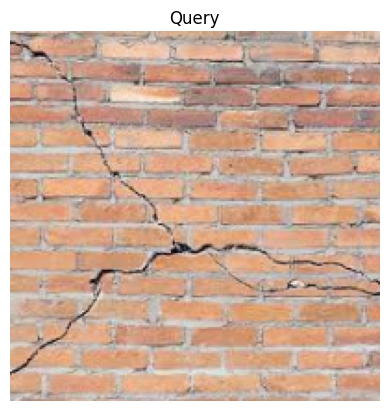

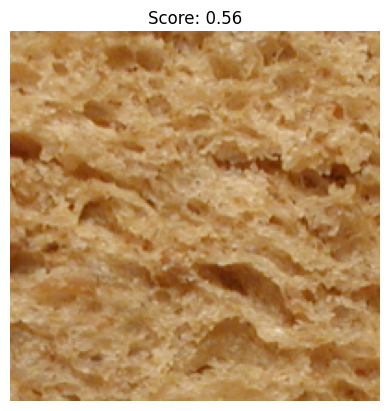

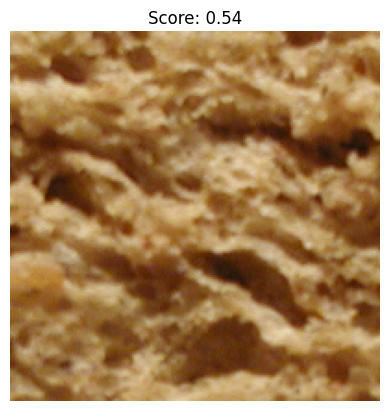

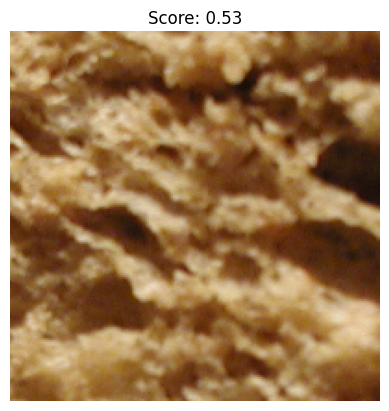

In [11]:
# Case Study 5: Industrial Quality Inspection – Detecting Defective Products
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics.pairwise import cosine_similarity
dataset_path = "D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/KTH TIPS-2/KTH_TIPS"
query_path = "D:/BS AI/6th Semester/Mids/Computing Vision Lab/Lab Tasks/23108125/M21.jpg"
def feature(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hist = cv2.calcHist([gray],[0],None,[256],[0,256])
    cv2.normalize(hist,hist)
    return hist.flatten()
query = cv2.imread(query_path)
if query is None:
    raise ValueError("Query image not found!")
query = cv2.resize(query,(200,200))
query_feat = feature(query)
images, features = [], []
max_images = 150
count = 0
for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(root,file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img,(200,200))
            images.append(img)
            features.append(feature(img))
            count += 1
            if count >= max_images:
                break
    if count >= max_images:
        break
scores = [cosine_similarity([query_feat],[f])[0][0] for f in features]
idx = np.argsort(scores)[::-1][:3]
plt.imshow(cv2.cvtColor(query,cv2.COLOR_BGR2RGB))
plt.title("Query")
plt.axis("off")
plt.show()
for i in idx:
    plt.imshow(cv2.cvtColor(images[i],cv2.COLOR_BGR2RGB))
    plt.title(f"Score: {scores[i]:.2f}")
    plt.axis("off")
    plt.show()